NOTE: VEP annotation of all guides

In [1]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm
import math

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [3]:
#zscores file
#EG_zscores_smooth_hits= pd.read_excel("data/plots/FindHits/EG_zscores_smooth_hits.xlsx")
#EG_zscores = pd.read_csv("data/4_Screen_zscores/EG/EG_zscores_min.csv")
#MC_zscores = pd.read_csv("data/4_Screen_zscores/MC/MC_zscores_min.csv")
#zscores = pd.read_csv("data/Testing/All_hits_original_(1columncondition_duplicatedGuides).csv", sep=",")
zscores_control = pd.read_csv("data/4_Screen_zscores/Merge_Control.csv")
zscores_plasmid = pd.read_csv("data/4_Screen_zscores/Merge_Plasmid.csv")

In [22]:
#Beagle-generated file EG
EG_beagle = pd.read_csv("data/1_Beagle_design_files/EG/EG-guides.txt", sep="\t")
MC_beagle = pd.read_csv("data/1_Beagle_design_files/MC/MC_guides.txt", sep="\t")

# Data Inspection

In [4]:
print(f'z-scores control shape: {zscores_control.shape}')
print(f'z-scores plasmid shape: {zscores_plasmid.shape}')

z-scores control shape: (77877, 18)
z-scores plasmid shape: (77877, 24)


In [5]:
for col in zscores_control.columns:
    print(col)

Guide
Gene
Editor
A375_PIC_Control
A375_SCH_Control
A375_LIN_Control
HT29_PIC_Control_EG
HT29_SCH_Control
HT29_LIN_Control
H23_ADAG_Control
H23_SOTOR_Control
HT29_DEB-CET_Control
HT29_PIC_Control_MC
HT29_TRAM_Control
PC9_GEFIT_Control
PC9_OSIM_Control
MHHES1_NIRAP_Control
MHHES1_OLAP_Control


In [6]:
for col in zscores_plasmid.columns:
    print(col)

Guide
Gene
Editor
A375_PIC_Plasmid
A375_SCH_Plasmid
A375_LIN_Plasmid
HT29_PIC_Plasmid_EG
HT29_SCH_Plasmid
HT29_LIN_Plasmid
A375_DO_Plasmid
HT29_DO_Plasmid
H23_ADAG_Plasmid
H23_SOTOR_Plasmid
HT29_DEB-CET_Plasmid
HT29_PIC_Plasmid_MC
HT29_TRAM_Plasmid
PC9_GEFIT_Plasmid
PC9_OSIM_Plasmid
MHHES1_NIRAP_Plasmid
MHHES1_OLAP_Plasmid
H23_Control_Plasmid
HT29_Control_Plasmid
PC9_Control_Plasmid
MHHES1_Control_Plasmid


### Duplicates

In [7]:
#Check duplicates
duplicates = zscores_control[zscores_control.duplicated(subset=['Guide', 'Editor'], keep=False)]
duplicates = duplicates.sort_values(by='Guide')
duplicates.head()

,Guide,Gene,Editor,A375_PIC_Control,A375_SCH_Control,A375_LIN_Control,HT29_PIC_Control_EG,HT29_SCH_Control,HT29_LIN_Control,H23_ADAG_Control,H23_SOTOR_Control,HT29_DEB-CET_Control,HT29_PIC_Control_MC,HT29_TRAM_Control,PC9_GEFIT_Control,PC9_OSIM_Control,MHHES1_NIRAP_Control,MHHES1_OLAP_Control
3676,AAGGTCATCAACTCCCAAAC,ERBB3,CBE,-0.511926,-0.232892,0.532032,-0.033422,-1.180418,-0.650421,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3678,AAGGTCATCAACTCCCAAAC,EGFR,CBE,-0.511926,-0.232892,0.532032,-0.033422,-1.180418,-0.650421,0.170892,-1.059833,0.705661,0.317864,-1.108477,0.130915,-1.076500,NaN,NaN
11661,AGCTCCAGACATCACTCTGG,EGFR,CBE,-0.163528,-0.289178,0.853565,0.808474,-4.909782,-0.739178,-1.652807,0.581957,0.158576,-0.426644,-6.016470,1.512103,-0.585263,NaN,NaN
11662,AGCTCCAGACATCACTCTGG,ERBB3,CBE,-0.163528,-0.289178,0.853565,0.808474,-4.909782,-0.739178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14420,AGTTGGCCATGGAGTCGATG,MAP2K1,CBE,0.547827,-1.571410,-1.803915,-0.886750,-1.336677,-0.050817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
len(duplicates)

40

In [9]:
zscores_plasmid.head()

,Guide,Gene,Editor,A375_PIC_Plasmid,A375_SCH_Plasmid,A375_LIN_Plasmid,HT29_PIC_Plasmid_EG,HT29_SCH_Plasmid,HT29_LIN_Plasmid,A375_DO_Plasmid,HT29_DO_Plasmid,H23_ADAG_Plasmid,H23_SOTOR_Plasmid,HT29_DEB-CET_Plasmid,HT29_PIC_Plasmid_MC,HT29_TRAM_Plasmid,PC9_GEFIT_Plasmid,PC9_OSIM_Plasmid,MHHES1_NIRAP_Plasmid,MHHES1_OLAP_Plasmid,H23_Control_Plasmid,HT29_Control_Plasmid,PC9_Control_Plasmid,MHHES1_Control_Plasmid
0,AAAAAAAAAAACTAAGAGTT,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.339885,-0.435793,-0.130954,0.150758,-0.000405,-0.267878,-0.265840,0.749878,0.623857,-0.793901,0.248229,-0.087339,0.352839
1,AAAAAAAAAAACTAAGAGTT,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.239891,-0.425877,0.509103,-0.343729,0.275384,0.167677,-0.163542,NaN,NaN,-0.605231,-0.248019,-0.133027,NaN
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.288042,-0.084146,0.023579,0.232187,0.149661,0.410165,0.176574,0.609217,0.310484,0.040756,-0.173223,0.297107,0.650107
3,AAAAAAAAAAGTAAGCTTCA,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.193041,-0.125730,0.252409,-0.025515,0.031043,-0.760856,-0.054741,NaN,NaN,-0.272949,-0.236611,-0.022693,NaN
4,AAAAAAAAAATCAATGGTGG,BCL2,ABE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.125899,-0.283770,-0.221515,0.628496,0.313693,0.381266,0.106376,-0.790841,0.117541,1.152411,0.029326,0.044886,-0.840669


# Classify Hits

In [10]:
def classify_hits(X_):
    X=X_.copy()
    exclude_cols = ['Guide', 'Gene', 'Editor'] 
    zscore_cols = [col for col in X.columns if col not in exclude_cols]

    for cond in zscore_cols:
        print(f"Processing condition: {cond}")

        all_z = X[cond]
        neg_ctrl_z = X.loc[X['Gene'] == 'Intergenic control', cond]

        mu = neg_ctrl_z.mean(skipna=True)
        sigma = neg_ctrl_z.std(skipna=True)

        # Initialize pvals and fdrs with NaNs
        pvals = np.full_like(all_z, np.nan, dtype=np.float64)
        fdrs = np.full_like(all_z, np.nan, dtype=np.float64)

        # Indices where all_z is not NaN
        valid_idx = all_z.notna()

        # Compute p-values only for valid entries
        z_scores = (all_z[valid_idx] - mu) / sigma
        pvals_valid = 2 * norm.sf(np.abs(z_scores))

        # FDR correction
        _, fdrs_valid, _, _ = multipletests(pvals_valid, alpha=0.05, method='fdr_bh')

        # Assign back to full arrays
        pvals[valid_idx] = pvals_valid
        fdrs[valid_idx] = fdrs_valid

        # Add results to dataframe
        X[f"{cond}_pval"] = pvals
        X[f"{cond}_fdr"] = fdrs

        print(f"Condition: {cond}")
        print(f"Negative controls count: {neg_ctrl_z.count()}")
        print(f"Negative control mean: {mu}, std: {sigma}")
        print(f"Any NaN in pvals? {np.isnan(pvals).any()}")
        print(f"All finite pvals? {np.isfinite(pvals[valid_idx]).all()}")


    def classify_hit(z, fdr, threshold=0.05):
        if fdr < threshold:
            if z > 0:
                return "positive"
            elif z < 0:
                return "negative"
        return "non-hit"

    for cond in zscore_cols:
        z_col = cond
        fdr_col = f"{cond}_fdr"
        label_col = f"{cond}_hit"

        X[label_col] = X.apply(
            lambda row: classify_hit(row[z_col], row[fdr_col]),
            axis=1
        )
    return X

In [11]:
zscores_plasmid= classify_hits(zscores_plasmid)

Processing condition: A375_PIC_Plasmid
Condition: A375_PIC_Plasmid
Negative controls count: 1000
Negative control mean: -0.027148615887439064, std: 0.3926930375214831
Any NaN in pvals? True
All finite pvals? True
Processing condition: A375_SCH_Plasmid
Condition: A375_SCH_Plasmid
Negative controls count: 1000
Negative control mean: -0.1271931598541124, std: 0.5424318260656481
Any NaN in pvals? True
All finite pvals? True
Processing condition: A375_LIN_Plasmid
Condition: A375_LIN_Plasmid
Negative controls count: 1000
Negative control mean: -0.015733007259847595, std: 0.4407530921231039
Any NaN in pvals? True
All finite pvals? True
Processing condition: HT29_PIC_Plasmid_EG
Condition: HT29_PIC_Plasmid_EG
Negative controls count: 1000
Negative control mean: -0.016864778139225885, std: 0.3787441709216337
Any NaN in pvals? True
All finite pvals? True
Processing condition: HT29_SCH_Plasmid
Condition: HT29_SCH_Plasmid
Negative controls count: 1000
Negative control mean: -0.06496652858053265, st

In [19]:
zscores_plasmid.head()

,Guide,Gene,Editor,A375_PIC_Plasmid,A375_SCH_Plasmid,A375_LIN_Plasmid,HT29_PIC_Plasmid_EG,HT29_SCH_Plasmid,HT29_LIN_Plasmid,A375_DO_Plasmid,HT29_DO_Plasmid,H23_ADAG_Plasmid,H23_SOTOR_Plasmid,HT29_DEB-CET_Plasmid,HT29_PIC_Plasmid_MC,HT29_TRAM_Plasmid,PC9_GEFIT_Plasmid,PC9_OSIM_Plasmid,MHHES1_NIRAP_Plasmid,MHHES1_OLAP_Plasmid,H23_Control_Plasmid,HT29_Control_Plasmid,PC9_Control_Plasmid,MHHES1_Control_Plasmid,A375_PIC_Plasmid_pval,A375_PIC_Plasmid_fdr,A375_SCH_Plasmid_pval,A375_SCH_Plasmid_fdr,A375_LIN_Plasmid_pval,A375_LIN_Plasmid_fdr,HT29_PIC_Plasmid_EG_pval,HT29_PIC_Plasmid_EG_fdr,HT29_SCH_Plasmid_pval,HT29_SCH_Plasmid_fdr,HT29_LIN_Plasmid_pval,HT29_LIN_Plasmid_fdr,A375_DO_Plasmid_pval,A375_DO_Plasmid_fdr,HT29_DO_Plasmid_pval,HT29_DO_Plasmid_fdr,H23_ADAG_Plasmid_pval,H23_ADAG_Plasmid_fdr,H23_SOTOR_Plasmid_pval,H23_SOTOR_Plasmid_fdr,HT29_DEB-CET_Plasmid_pval,HT29_DEB-CET_Plasmid_fdr,HT29_PIC_Plasmid_MC_pval,HT29_PIC_Plasmid_MC_fdr,HT29_TRAM_Plasmid_pval,HT29_TRAM_Plasmid_fdr,PC9_GEFIT_Plasmid_pval,PC9_GEFIT_Plasmid_fdr,PC9_OSIM_Plasmid_pval,PC9_OSIM_Plasmid_fdr,MHHES1_NIRAP_Plasmid_pval,MHHES1_NIRAP_Plasmid_fdr,MHHES1_OLAP_Plasmid_pval,MHHES1_OLAP_Plasmid_fdr,H23_Control_Plasmid_pval,H23_Control_Plasmid_fdr,HT29_Control_Plasmid_pval,HT29_Control_Plasmid_fdr,PC9_Control_Plasmid_pval,PC9_Control_Plasmid_fdr,MHHES1_Control_Plasmid_pval,MHHES1_Control_Plasmid_fdr,A375_PIC_Plasmid_hit,A375_SCH_Plasmid_hit,A375_LIN_Plasmid_hit,HT29_PIC_Plasmid_EG_hit,HT29_SCH_Plasmid_hit,HT29_LIN_Plasmid_hit,A375_DO_Plasmid_hit,HT29_DO_Plasmid_hit,H23_ADAG_Plasmid_hit,H23_SOTOR_Plasmid_hit,HT29_DEB-CET_Plasmid_hit,HT29_PIC_Plasmid_MC_hit,HT29_TRAM_Plasmid_hit,PC9_GEFIT_Plasmid_hit,PC9_OSIM_Plasmid_hit,MHHES1_NIRAP_Plasmid_hit,MHHES1_OLAP_Plasmid_hit,H23_Control_Plasmid_hit,HT29_Control_Plasmid_hit,PC9_Control_Plasmid_hit,MHHES1_Control_Plasmid_hit
0,AAAAAAAAAAACTAAGAGTT,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.339885,-0.435793,-0.130954,0.150758,-0.000405,-0.267878,-0.265840,0.749878,0.623857,-0.793901,0.248229,-0.087339,0.352839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.470665,0.999998,0.392298,0.999971,0.970618,0.999923,0.689856,0.999835,0.851306,0.999954,0.309412,0.924018,0.926184,0.999896,0.184212,0.999916,0.252963,0.999974,0.133826,0.943126,0.632012,0.999923,0.416825,0.999814,0.439918,0.995291,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit
1,AAAAAAAAAAACTAAGAGTT,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.239891,-0.425877,0.509103,-0.343729,0.275384,0.167677,-0.163542,NaN,NaN,-0.605231,-0.248019,-0.133027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.655863,0.999998,0.403147,0.999971,0.476851,0.999923,0.866767,0.999835,0.617693,0.999954,0.551400,0.924018,0.985059,0.999896,NaN,NaN,NaN,NaN,0.251700,0.999991,0.929927,0.999923,0.364566,0.999814,NaN,NaN,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.288042,-0.084146,0.023579,0.232187,0.149661,0.410165,0.176574,0.609217,0.310484,0.040756,-0.173223,0.297107,0.650107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.587436,0.999998,0.868197,0.999971,0.841720,0.999923,0.622444,0.999835,0.721060,0.999954,0.717806,0.934848,0.697262,0.999896,0.258957,0.999916,0.464710,0.999974,0.950366,0.999991,0.998005,0.999923,0.988336,0.999814,0.251370,0.995291,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit
3,AAAAAAAAAAGTAAGCTTCA,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.193041,-0.125730,0.252409,-0.025515,0.031043,-0.760856,-0.054741,NaN,NaN,-0.272949,-0.236611,-0.022693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [13]:
#export to csv
zscores_plasmid.to_csv("data/4_Screen_zscores/Merge_Plasmid_Hit_Class.csv", index=False)

# Preprocessing

In [15]:
#Dataframe to keep track of the numbers of rows throughout the process
tracking_row_count = pd.DataFrame(columns=["Step", "Rows count"])

# Function to log the number of rows at each step
def log_step(tracking_row_count, step_name, df):
    new_entry = pd.DataFrame({"Step": [step_name], "Rows count": [len(df)]})
    return pd.concat([tracking_row_count, new_entry], ignore_index=True)

In [14]:
#Dataframe to keep track of the numbers of unique guides throughout the process
tracking_unique_guides = pd.DataFrame(columns=["Step", "Unique guides count"])
# Function to log the number of unique guides at each step
def log_unique_guides(tracking_unique_guides, step_name, df):
    new_entry = pd.DataFrame({"Step": [step_name], "Unique guides count": [df['Guide'].nunique()]})
    return pd.concat([tracking_unique_guides, new_entry], ignore_index=True)

In [16]:
tracking_row_count = log_step(tracking_row_count, "Initial z-scores", zscores_plasmid)
tracking_unique_guides = log_unique_guides(tracking_unique_guides, "Initial z-scores", zscores_plasmid)

In [17]:
tracking_unique_guides

,Step,Unique guides count
0,Initial z-scores,55041


In [18]:
tracking_row_count

,Step,Rows count
0,Initial z-scores,77877


### Eliminate guides that target two different genes 

In [23]:
guides_target_dif_genes_EG = EG_beagle[EG_beagle.duplicated(subset=['sgRNA Sequence', 'Edit Type'], keep=False)]
guides_target_dif_genes_EG = guides_target_dif_genes_EG.sort_values(by=['sgRNA Sequence', 'Edit Type'])
guides_target_dif_genes_EG.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
3054,ENST00000275493.7,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,AAGGTCATCAACTCCCAAAC,TCCAAAGGTCATCAACTCCCAAACAGTCAC,AG,55198725,antisense,55198738T>C,A_7,2723T>C,Met908Thr,Missense,NaN,NaN
12712,ENST00000267101.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000012.12,ENSG00000065361,ERBB3,+,ENST00000267101.8,CDS,AAGGTCATCAACTCCCAAAC,CCCGAAGGTCATCAACTCCCAAACTGTCAC,TG,56098767,antisense,56098780T>C,A_7,2714T>C,Met905Thr,Missense,NaN,NaN
3055,ENST00000275493.7,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,AAGGTCATCAACTCCCAAAC,TCCAAAGGTCATCAACTCCCAAACAGTCAC,AG,55198725,antisense,55198739G>A,C_6,2724G>A,Met908Ile,Missense,NaN,NaN
12713,ENST00000267101.8,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000012.12,ENSG00000065361,ERBB3,+,ENST00000267101.8,CDS,AAGGTCATCAACTCCCAAAC,CCCGAAGGTCATCAACTCCCAAACTGTCAC,TG,56098767,antisense,56098781G>A,C_6,2715G>A,Met905Ile,Missense,NaN,NaN
3008,ENST00000275493.7,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,AGCTCCAGACATCACTCTGG,CCGTAGCTCCAGACATCACTCTGGTGGGTA,TG,55192819,antisense,55192832T>C,A_7,2692T>C,Trp898Arg,Missense,NaN,NaN


In [24]:
len(guides_target_dif_genes_EG)

80

In [25]:
guides_target_dif_genes_EG['Target Gene Symbol'].value_counts()

Target Gene Symbol
MAP2K1    30
MAP2K2    30
EGFR      10
ERBB3     10
Name: count, dtype: int64

In [26]:
guides_target_dif_genes_MC = MC_beagle[MC_beagle.duplicated(subset=['sgRNA Sequence', 'Edit Type'], keep=False)]
guides_target_dif_genes_MC = guides_target_dif_genes_MC.sort_values(by=['sgRNA Sequence', 'Edit Type'])
guides_target_dif_genes_MC.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
18310,ENST00000307102,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000015.10,ENSG00000169032,MAP2K1,+,ENST00000307102.10,CDS,AGTTGGCCATGGAGTCGATG,AAGGAGTTGGCCATGGAGTCGATGAGCTGC,AG,66481831,antisense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19816,ENST00000262948,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000019.10,ENSG00000126934,MAP2K2,-,ENST00000262948.10,CDS,AGTTGGCCATGGAGTCGATG,AAGGAGTTGGCCATGGAGTCGATGAGCTGG,AG,4101048,antisense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18311,ENST00000307102,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000015.10,ENSG00000169032,MAP2K1,+,ENST00000307102.10,CDS,AGTTGGCCATGGAGTCGATG,AAGGAGTTGGCCATGGAGTCGATGAGCTGC,AG,66481831,antisense,"66481843G>A, 66481844G>A","C_8, C_7","657G>A, 658G>A","Met219Ile, Ala220Thr","Missense, Missense",NaN,NaN
19817,ENST00000262948,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000019.10,ENSG00000126934,MAP2K2,-,ENST00000262948.10,CDS,AGTTGGCCATGGAGTCGATG,AAGGAGTTGGCCATGGAGTCGATGAGCTGG,AG,4101048,antisense,"4101055C>T, 4101054C>T","C_8, C_7","669G>A, 670G>A","Met223Ile, Ala224Thr","Missense, Missense",NaN,NaN
18324,ENST00000307102,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000015.10,ENSG00000169032,MAP2K1,+,ENST00000307102.10,CDS,CACGAAGGAGTTGGCCATGG,TGCCCACGAAGGAGTTGGCCATGGAGTCGA,AG,66481839,antisense,66481853T>C;66481854T>C,A_6;A_5,667T>C;668T>C,Phe223Pro,Missense,NaN,NaN


In [27]:
len(guides_target_dif_genes_MC)

60

In [28]:
guides_target_dif_genes_MC['Target Gene Symbol'].value_counts()

Target Gene Symbol
MAP2K1    30
MAP2K2    30
Name: count, dtype: int64

In [29]:
guides_target_dif_genes_EG_MC = pd.concat([guides_target_dif_genes_EG, guides_target_dif_genes_MC])

In [30]:
#Get the sgRNA sequences of guides that target multiple genes
multi_target_guides = guides_target_dif_genes_EG_MC['sgRNA Sequence'].drop_duplicates()

In [31]:
len(multi_target_guides)

20

In [33]:
#Check how many of these guides are in the zscores file
zscores_plasmid_in_multi_tagert_guides=zscores_plasmid[zscores_plasmid['Guide'].isin(multi_target_guides)]

In [34]:
len(zscores_plasmid_in_multi_tagert_guides)

60

In [35]:
zscores_plasmid_in_multi_tagert_guides['Gene'].value_counts()

Gene
MAP2K2    30
MAP2K1    15
EGFR      10
ERBB3      5
Name: count, dtype: int64

In [36]:
# Delete the guides that target multiple genes from the zscores file
zscores_plasmid_filtered = zscores_plasmid[~zscores_plasmid['Guide'].isin(multi_target_guides)]

In [37]:
print(f' Filtered z-scores plasmid shape: {zscores_plasmid_filtered.shape}')

 Filtered z-scores plasmid shape: (77817, 87)


In [38]:
tracking_row_count = log_step(tracking_row_count, "Filtered multi-target guides", zscores_plasmid_filtered)
tracking_unique_guides = log_unique_guides(tracking_unique_guides, "Filtered multi-target guides", zscores_plasmid_filtered)

In [39]:
tracking_unique_guides

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021


In [40]:
tracking_row_count

,Step,Rows count
0,Initial z-scores,77877
1,Filtered multi-target guides,77817


## Dataset Format Change

#### Reshape and Filter 

In [41]:
def filter_reshape_zscores_old(dataframe, comparison='Plasmid', include_hit_label='True'):
    """
    Extracts z-scores and hit labels for a given comparison ('Control' or 'Plasmid'),
    and returns a long-format condition-per-row DataFrame.

    Parameters:
    - dataframe: input z-scores DataFrame
    - comparison: str, 'Control' or 'Plasmid'
    - include_hit_label: str or bool
        'True'  → include all hit_class values
        'False' → exclude hit_class column
        'hit'   → include only rows where hit_class is 'positive' or 'negative'

    Returns:
    - DataFrame with: Guide, Editor, Gene, Cell_Line, Drug, zscore[, hit_class]
    """

    meta_cols = ['Guide', 'Editor', 'Gene']

    #Define the z-score columns name pattern and select only target columns
    zscore_pattern = re.compile(f'^[^_]+_[^_]+_{comparison}$')
    zscore_cols = [col for col in dataframe.columns if zscore_pattern.match(col) and col.split('_')[1] not in ['DO', 'Control']]
   
    # Melt z-scores
    zscores_df = dataframe[meta_cols + zscore_cols].melt(
        id_vars=meta_cols,
        var_name='condition',
        value_name='zscore'
    )

    # Prepare final dataframe
    final_df = zscores_df.copy()

    if include_hit_label != 'False':
        #Define the hit columns name pattern and select only the target columns
        hit_pattern = re.compile(f'^[^_]+_[^_]+_{comparison}_hit$')
        hit_cols = [col for col in dataframe.columns if hit_pattern.match(col) and col.split('_')[1] not in ['DO', 'Control']]
        # Melt hit_class and align column names
        hit_df = dataframe[meta_cols + hit_cols].melt(
            id_vars=meta_cols,
            var_name='condition',
            value_name='Hit_class'
        )
        hit_df['condition'] = hit_df['condition'].str.replace(f"_{comparison}_hit$", f"_{comparison}", regex=True)
        
        # Merge hit info into final df
        final_df = pd.merge(final_df, hit_df, on=meta_cols + ['condition'], how='left')

        # Filter if only hit labels are requested
        if include_hit_label == 'hit':
            final_df = final_df[final_df['Hit_class'].isin(['positive', 'negative'])]

    # Extract Cell Line and Drug from condition
    condition_split = final_df['condition'].str.extract(r'^(?P<Cell_Line>[^_]+)_(?P<Drug>.+)_' + re.escape(comparison) + r'$')
    final_df = pd.concat([final_df, condition_split], axis=1)

    # Drop rows with NaN z-scores
    final_df = final_df.dropna(subset=['zscore'], ignore_index=True)

    # Final column order
    columns = ['Guide', 'Editor', 'Gene', 'Cell_Line', 'Drug', 'zscore']
    if include_hit_label != 'False':
        columns.append('Hit_class')

    return final_df[columns]

In [43]:
def filter_reshape_zscores(dataframe, include_hit_label='True'):
    """
    Extracts z-scores and hit labels from a z-score dataframe and returns a long-format condition-per-row DataFrame.

    Parameters:
    - dataframe: input z-scores DataFrame
    - include_hit_label: str or bool
        'True'  → include all hit_class values
        'False' → exclude hit_class column
        'hit'   → include only rows where hit_class is 'positive' or 'negative'

    Returns:
    - DataFrame with: Guide, Editor, Gene, Cell_Line, Drug, zscore[, hit_class, Source]
    """

    meta_cols = ['Guide', 'Editor', 'Gene']

    # Allow 3 or 4 parts in column names
    zscore_pattern = re.compile(r'^[^_]+_[^_]+_[^_]+(?:_(MC|EG))?$')
    zscore_cols = [col for col in dataframe.columns if zscore_pattern.match(col) and col.split('_')[1] not in ['DO', 'Control']]
   
    # Melt z-scores
    zscores_df = dataframe[meta_cols + zscore_cols].melt(
        id_vars=meta_cols,
        var_name='condition',
        value_name='zscore'
    )

    # Prepare final dataframe
    final_df = zscores_df.copy()

    if include_hit_label != 'False':
        # Match 4-part columns ending in _hit
        hit_pattern = re.compile(r'^[^_]+_[^_]+_[^_]+(?:_(MC|EG))?_hit$')
        hit_cols = [col for col in dataframe.columns if hit_pattern.match(col) and col.split('_')[1] not in ['DO', 'Control']]
        hit_df = dataframe[meta_cols + hit_cols].melt(
            id_vars=meta_cols,
            var_name='condition',
            value_name='Hit_class'
        )
        hit_df['condition'] = hit_df['condition'].str.replace(r"_hit$", "", regex=True)
        
        # Merge hit info into final df
        final_df = pd.merge(final_df, hit_df, on=meta_cols + ['condition'], how='left')

        # Filter if only hit labels are requested
        if include_hit_label == 'hit':
            final_df = final_df[final_df['Hit_class'].isin(['positive', 'negative'])]

    # Support 3- or 4-part condition strings
    condition_split = final_df['condition'].str.extract(
        r'^(?P<Cell_Line>[^_]+)_(?P<Drug>[^_]+)_(?P<Comparison>[^_]+)(?:_(?P<Source>[^_]+))?$'
    )
    final_df = pd.concat([final_df, condition_split], axis=1)

    # Drop rows with NaN zscore 
    final_df = final_df.dropna(subset=['zscore'], ignore_index=True)

    # Final column order
    columns = ['Guide', 'Editor', 'Gene', 'Cell_Line', 'Drug', 'zscore']
    if include_hit_label != 'False':
        columns.append('Hit_class')
    columns.append('Source')

    return final_df[columns]

In [44]:
zscores_plasmid_rs = filter_reshape_zscores(zscores_plasmid_filtered, include_hit_label='True')
zscores_plasmid_rs.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.781556,non-hit,NaN
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,-0.275840,non-hit,NaN
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,0.449610,non-hit,NaN
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.188996,non-hit,NaN


In [45]:
print(f' Reshaped z-scores plasmid shape: {zscores_plasmid_rs.shape}')

 Reshaped z-scores plasmid shape: (601352, 8)


In [46]:
zscores_plasmid_rs['zscore'].isna().sum()

np.int64(0)

In [47]:
tracking_row_count = log_step(tracking_row_count, "Reshaped z-scores", zscores_plasmid_rs)
tracking_unique_guides = log_unique_guides(tracking_unique_guides, "Reshaped z-scores", zscores_plasmid_rs)

In [48]:
tracking_row_count

,Step,Rows count
0,Initial z-scores,77877
1,Filtered multi-target guides,77817
2,Reshaped z-scores,601352


In [49]:
tracking_unique_guides

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021
2,Reshaped z-scores,55021


#### Check for duplicated rows

In [50]:
duplicated_rows_zscores_plasmid = zscores_plasmid_rs[zscores_plasmid_rs.duplicated(keep=False)]

In [51]:
len(duplicated_rows_zscores_plasmid)

0

In [52]:
#Export to CSV
zscores_plasmid_rs.to_csv("data/4_Screen_zscores/Merge_Plasmid_Hit_Class_Reshaped.csv", index=False)

## Beagle Files

In [53]:
#Replace 'C-T' with 'CBE'
EG_beagle["Edit Type"] = EG_beagle["Edit Type"].replace("C-T", "CBE")
MC_beagle["Edit Type"] = MC_beagle["Edit Type"].replace("C-T", "CBE")
MC_beagle["Edit Type"] = MC_beagle["Edit Type"].replace("A-G", "ABE")

In [54]:
#Filter EG beagle for CBE edits
EG_beagle_cbe = EG_beagle[EG_beagle["Edit Type"]=='CBE']

In [56]:
EG_beagle_cbe.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
1,ENST00000275493.7,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,CGCATCGCTGCTCCCCGAAG,GGGTCGCATCGCTGCTCCCCGAAGAGCTCG,AG,55019263,antisense,"55019275G>A, 55019277G>A","C_8, C_6","-3G>A, -1G>A","(NC), (NC)","UTR, UTR",NaN,NaN
3,ENST00000275493.7,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,GTCGCATCGCTGCTCCCCGA,GAGGGTCGCATCGCTGCTCCCCGAAGAGCT,AG,55019265,antisense,"55019277G>A, 55019280G>A","C_8, C_5","-1G>A, 3G>A","(NC), Met1Ile","UTR, Missense",NaN,NaN
5,ENST00000275493.7,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,AGGGTCGCATCGCTGCTCCC,CCGGAGGGTCGCATCGCTGCTCCCCGAAGA,CG,55019268,antisense,"55019280G>A, 55019282G>A","C_8, C_6","3G>A, 5G>A","Met1Ile, Arg2Gln","Missense, Missense",NaN,NaN
7,ENST00000275493.7,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,GGAGCAGCGATGCGACCCTC,TCGGGGAGCAGCGATGCGACCCTCCGGGAC,CG,55019269,sense,"55019273C>T, 55019276C>T","C_5, C_8","-5C>T, -2C>T","(NC), (NC)","UTR, UTR",NaN,NaN
9,ENST00000275493.7,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,GAGCAGCGATGCGACCCTCC,CGGGGAGCAGCGATGCGACCCTCCGGGACG,GG,55019270,sense,"55019273C>T, 55019276C>T","C_4, C_7","-5C>T, -2C>T","(NC), (NC)","UTR, UTR",NaN,NaN


In [57]:
MC_beagle.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
0,ENST00000311936,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,GTAATTATGTAAATACAATT,GTGTGTAATTATGTAAATACAATTTGTACT,TG,25209787,sense,"25209803T>C, 25209800T>C","A_4, A_7","559A>G, 562A>G","Ile187Val, Met188Val","Missense, Missense",NaN,NaN
1,ENST00000311936,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,GTAATTATGTAAATACAATT,GTGTGTAATTATGTAAATACAATTTGTACT,TG,25209787,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENST00000311936,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATTTACATAATTACACACTT,TTGTATTTACATAATTACACACTTTGTCTT,TG,25209793,antisense,"25209799A>G, 25209797A>G","A_7, A_5","563T>C, 565T>C","Met188Thr, Ter189Gln","Missense, Missense",NaN,NaN
3,ENST00000311936,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATTTACATAATTACACACTT,TTGTATTTACATAATTACACACTTTGTCTT,TG,25209793,antisense,25209798C>T,C_6,564G>A,Met188Ile,Missense,NaN,NaN
4,ENST00000311936,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATAATTACACACTTTGTCTT,TTACATAATTACACACTTTGTCTTTGACTT,TG,25209799,antisense,"25209805A>G, 25209802A>G","A_7, A_4","557T>C, 560T>C","Val186Ala, Ile187Thr","Missense, Missense",NaN,NaN


In [58]:
#Check if there are any duplicated guides in beagle 
duplicated_guides_beagle_EG=EG_beagle_cbe[EG_beagle_cbe.duplicated(subset=["sgRNA Sequence"], keep=False)]
duplicated_guides_beagle_MC=MC_beagle[MC_beagle.duplicated(subset=["Edit Type", "sgRNA Sequence"], keep=False)]
duplicated_guides_beagle_EG = duplicated_guides_beagle_EG.sort_values(by=["sgRNA Sequence"])
duplicated_guides_beagle_MC = duplicated_guides_beagle_MC.sort_values(by=["sgRNA Sequence", "Edit Type"])

In [59]:
print(f'EG: {len(duplicated_guides_beagle_EG)}')
print(f'MC: {len(duplicated_guides_beagle_MC)}')

EG: 40
MC: 60


### Concatenate EG and MC beagle files

In [60]:
#MC_beagle['Source'] = 'MC'
#EG_beagle_cbe['Source'] = 'EG'
MC_EG_beagle = pd.concat([MC_beagle, EG_beagle_cbe], ignore_index=True)

In [61]:
#drop 'Input' column because there is a mismatch in the transcript ID format. EG includes the version.
MC_EG_beagle = MC_EG_beagle.drop(columns=['Input'])

#Drop 'PAM Sequence' column because it is not needed for the analysis and there is a mismatch in the PAM sequence length.
MC_EG_beagle = MC_EG_beagle.drop(columns=['PAM Sequence'])

In [62]:
MC_EG_beagle.head()

,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
0,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,GTAATTATGTAAATACAATT,GTGTGTAATTATGTAAATACAATTTGTACT,25209787,sense,"25209803T>C, 25209800T>C","A_4, A_7","559A>G, 562A>G","Ile187Val, Met188Val","Missense, Missense",NaN,NaN
1,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,GTAATTATGTAAATACAATT,GTGTGTAATTATGTAAATACAATTTGTACT,25209787,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATTTACATAATTACACACTT,TTGTATTTACATAATTACACACTTTGTCTT,25209793,antisense,"25209799A>G, 25209797A>G","A_7, A_5","563T>C, 565T>C","Met188Thr, Ter189Gln","Missense, Missense",NaN,NaN
3,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATTTACATAATTACACACTT,TTGTATTTACATAATTACACACTTTGTCTT,25209793,antisense,25209798C>T,C_6,564G>A,Met188Ile,Missense,NaN,NaN
4,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATAATTACACACTTTGTCTT,TTACATAATTACACACTTTGTCTTTGACTT,25209799,antisense,"25209805A>G, 25209802A>G","A_7, A_4","557T>C, 560T>C","Val186Ala, Ile187Thr","Missense, Missense",NaN,NaN


In [63]:
print(f' Beagle file after concatenation: {MC_EG_beagle.shape}')

 Beagle file after concatenation: (61726, 22)


### Check for duplicated entries

In [64]:
duplicates_beagle_MC_EG_1 = MC_EG_beagle[MC_EG_beagle.duplicated(subset=["Edit Type","sgRNA Sequence","Target Gene Symbol"], keep=False)]
duplicates_beagle_MC_EG_1 = duplicates_beagle_MC_EG_1.sort_values(by='sgRNA Sequence')

In [65]:
len(duplicates_beagle_MC_EG_1)

15140

In [430]:
duplicates_beagle_MC_EG_1['Source'].value_counts()

Source
MC    7570
EG    7570
Name: count, dtype: int64

In [66]:
#check for duplicated entries
duplicates_beagle_MC_EG = MC_EG_beagle[MC_EG_beagle.duplicated(keep=False)]
duplicates_beagle_MC_EG = duplicates_beagle_MC_EG.sort_values(by='sgRNA Sequence')

In [67]:
len(duplicates_beagle_MC_EG)

15140

### Drop duplicated entries

In [68]:
MC_EG_beagle_backup = MC_EG_beagle.copy()
#drop duplicated entries
MC_EG_beagle = MC_EG_beagle.drop_duplicates(ignore_index=True)

In [69]:
print(f'Length of MC_EG_beagle before dropping duplicates: {len(MC_EG_beagle_backup)}')
print(f'Length of MC_EG_beagle after dropping duplicates: {len(MC_EG_beagle)}')
print(f'Number of dropped duplicates: {len(MC_EG_beagle_backup) - len(MC_EG_beagle)}')

Length of MC_EG_beagle before dropping duplicates: 61726
Length of MC_EG_beagle after dropping duplicates: 54156
Number of dropped duplicates: 7570


In [70]:
#Confirm that there are no more duplicates
len(MC_EG_beagle[MC_EG_beagle.duplicated(keep=False)])

0

#### Check for missing guides in the Beagle Files

In [381]:
# Check if the beagle files contain all guides in zscores
missing_guides=zscores_control_rs[~zscores_control_rs['Guide'].isin(MC_EG_beagle['sgRNA Sequence'])].drop_duplicates(subset=['Guide'])

In [397]:
missing_guides_MC = MC_zscores[~MC_zscores['Guide'].isin(MC_beagle['sgRNA Sequence'])].drop_duplicates(subset=['Guide'])

In [391]:
missing_guides_target_genes = missing_guides[missing_guides['Gene'].isin(MC_EG_beagle['Target Gene Symbol'])]
missing_guides_target_genes = missing_guides_target_genes.sort_values(by='Guide')

In [398]:
missing_guides_target_genes_MC = missing_guides_MC[missing_guides_MC['Gene'].isin(MC_beagle['Target Gene Symbol'])]

In [399]:
len(missing_guides_target_genes_MC)

11604

In [400]:
missing_guides_EG = EG_zscores[~EG_zscores['Guide'].isin(EG_beagle_cbe['sgRNA Sequence'])].drop_duplicates(subset=['Guide'])

In [401]:
missing_guides_target_genes_EG = missing_guides_EG[missing_guides_EG['Gene'].isin(EG_beagle_cbe['Target Gene Symbol'])]

In [402]:
len(missing_guides_target_genes_EG)

0

In [372]:
MC_beagle['Target Gene Symbol'].value_counts()

Target Gene Symbol
EGFR      4500
PARP1     3602
BRAF      2448
PIK3CA    2434
AKT1      2222
MAP2K2    1928
PARP2     1792
MYC       1520
MAP2K1    1434
BCL2      1010
KRAS       432
Name: count, dtype: int64

In [383]:
len(missing_guides)

13287

In [384]:
len(missing_guides_target_genes)

11604

In [390]:
missing_guides_target_genes['Gene'].value_counts()

Gene
BRAF      2556
BCL2      2290
EGFR      1462
KRAS      1430
AKT1       979
PIK3CA     976
MYC        638
MAP2K1     516
PARP1      428
MAP2K2     288
PARP2       41
Name: count, dtype: int64

In [403]:
missing_guides_target_genes_MC.head()

,Guide,Gene,Editor,H_23_Adag_Control,H_23_Sotor_Control,H_23_T0_Control,HT_29_Deb_Cet_Control,HT_29_Pict_Control,HT_29_T0_Control,HT_29_Tram_Control,PC_9_Gefit_Control,PC_9_Osim_Control,PC_9_T0_Control,MHHES_1_Nirap_Control,MHHES_1_Olap_Control,MHHES_1_T0_Control,H_23_Adag_Plasmid,H_23_Sotor_Plasmid,H_23_T0_Plasmid,HT_29_Deb_Cet_Plasmid,HT_29_Pict_Plasmid,HT_29_T0_Plasmid,HT_29_Tram_Plasmid,PC_9_Gefit_Plasmid,PC_9_Osim_Plasmid,PC_9_T0_Plasmid,MHHES_1_Nirap_Plasmid,MHHES_1_Olap_Plasmid,MHHES_1_T0_Plasmid,H_23_Control_Plasmid,HT_29_Control_Plasmid,PC_9_Control_Plasmid,MHHES_1_Control_Plasmid
0,AAAAAAAAAAACTAAGAGTT,KRAS,ABE,0.349536,0.281788,-0.208892,-0.092111,-0.440937,-0.116991,0.237055,-0.323425,-0.429644,0.018421,0.742707,0.546180,-0.458646,0.339885,-0.435793,-1.561256,-0.130954,0.150758,0.645536,-0.000405,-0.267878,-0.265840,-0.358342,0.749878,0.623857,-0.320965,-0.793901,0.248229,-0.087339,0.352839
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,0.346023,0.635084,-0.919463,0.050661,0.711641,0.330146,0.578670,-0.279569,-0.361358,-0.523216,-0.079732,0.226823,-0.659557,-0.288042,-0.084146,-1.378824,0.023579,0.232187,0.425852,0.149661,0.410165,0.176574,0.167148,0.609217,0.310484,0.127588,0.040756,-0.173223,0.297107,0.650107
4,AAAAAAAAAATCAATGGTGG,BCL2,ABE,-0.042433,1.692755,0.387114,0.481643,1.075654,0.097135,0.700159,-0.779421,-0.548121,-0.152169,-0.228105,-0.752463,0.582669,-0.125899,-0.283770,-1.922740,-0.221515,0.628496,0.016402,0.313693,0.381266,0.106376,-0.335480,-0.790841,0.117541,-1.279929,1.152411,0.029326,0.044886,-0.840669
6,AAAAAAAAAATTAATGTCTT,KRAS,ABE,-0.285352,-0.489852,-0.228778,-4.440108,-0.377811,-0.023559,-1.357566,-0.209760,-1.251899,-0.596837,0.613627,0.502377,-0.347465,-0.190454,-0.032107,-1.413546,-0.050886,-0.094276,-0.073235,-0.086967,0.241040,-0.133649,-1.149569,0.372823,0.325133,-1.030949,-0.681175,-0.004662,0.229345,-0.025939
8,AAAAAAAAACTAAGAGTTTG,KRAS,ABE,-0.425668,-1.049779,-0.434330,-0.114128,-0.581658,0.504807,-0.734278,0.952603,0.223372,-0.057933,-0.467135,-0.272545,0.362248,-0.008844,-0.519143,-1.292751,-0.250659,-0.257694,-0.963834,0.000355,0.343049,0.081664,-0.869839,-0.454571,0.471084,-0.630218,-0.409410,0.597383,-0.195939,-0.484878


In [405]:
missing_guides_target_genes_MC['Guide'].to_csv('/Users/carolinapinto/Desktop/Tese/Data/MC/missing_guides_in_beagle_MC.txt', index=False, header=False)

In [406]:
missing_guides_target_genes_MC['Gene'].value_counts()

Gene
BRAF      2556
BCL2      2290
EGFR      1462
KRAS      1430
AKT1       979
PIK3CA     976
MYC        638
MAP2K1     516
PARP1      428
MAP2K2     288
PARP2       41
Name: count, dtype: int64

In [394]:
missing_guides_target_genes.head(20)

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Source
236616,AAAAAAAAAAACTAAGAGTT,ABE,KRAS,H23,ADAG,0.349536,NaN
236618,AAAAAAAAAAGTAAGCTTCA,ABE,KRAS,H23,ADAG,0.346023,NaN
236620,AAAAAAAAAATCAATGGTGG,ABE,BCL2,H23,ADAG,-0.042433,NaN
236622,AAAAAAAAAATTAATGTCTT,ABE,KRAS,H23,ADAG,-0.285352,NaN
236624,AAAAAAAAACTAAGAGTTTG,CBE,KRAS,H23,ADAG,0.805449,NaN
236626,AAAAAAAAAGGCAGCGGCGG,ABE,BCL2,H23,ADAG,0.779212,NaN
236628,AAAAAAAAAGTTCCAGGTGT,ABE,BCL2,H23,ADAG,-0.030160,NaN
236630,AAAAAAAAGGCAGCGGCGGC,ABE,BCL2,H23,ADAG,-0.554195,NaN
236632,AAAAAAAATCCCCTAAAAAA,CBE,KRAS,H23,ADAG,-0.590212,NaN
236634,AAAAAAACCGTTCACAGCTT,CBE,BRAF,H23,ADAG,-0.081933,NaN


In [396]:
MC_zscores[MC_zscores['Guide'] == 'AAAAAAAAAAGTAAGCTTCA']

,Guide,Gene,Editor,H_23_Adag_Control,H_23_Sotor_Control,H_23_T0_Control,HT_29_Deb_Cet_Control,HT_29_Pict_Control,HT_29_T0_Control,HT_29_Tram_Control,PC_9_Gefit_Control,PC_9_Osim_Control,PC_9_T0_Control,MHHES_1_Nirap_Control,MHHES_1_Olap_Control,MHHES_1_T0_Control,H_23_Adag_Plasmid,H_23_Sotor_Plasmid,H_23_T0_Plasmid,HT_29_Deb_Cet_Plasmid,HT_29_Pict_Plasmid,HT_29_T0_Plasmid,HT_29_Tram_Plasmid,PC_9_Gefit_Plasmid,PC_9_Osim_Plasmid,PC_9_T0_Plasmid,MHHES_1_Nirap_Plasmid,MHHES_1_Olap_Plasmid,MHHES_1_T0_Plasmid,H_23_Control_Plasmid,HT_29_Control_Plasmid,PC_9_Control_Plasmid,MHHES_1_Control_Plasmid
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,0.346023,0.635084,-0.919463,0.050661,0.711641,0.330146,0.578670,-0.279569,-0.361358,-0.523216,-0.079732,0.226823,-0.659557,-0.288042,-0.084146,-1.378824,0.023579,0.232187,0.425852,0.149661,0.410165,0.176574,0.167148,0.609217,0.310484,0.127588,0.040756,-0.173223,0.297107,0.650107
3,AAAAAAAAAAGTAAGCTTCA,KRAS,CBE,-0.339015,0.169475,0.004314,-0.652642,-0.273429,0.066113,-0.103004,-0.428180,0.882738,-0.293516,NaN,NaN,NaN,-0.193041,-0.125730,-0.671297,0.252409,-0.025515,-0.445681,0.031043,-0.760856,-0.054741,0.022675,NaN,NaN,NaN,-0.272949,-0.236611,-0.022693,NaN


# Merge z-scores and Beagle Files

In [71]:
#Rename 'Edit Type' and 'sgRNA Sequence' column from the Beagle file to avoid duplicate columns in the merge
MC_EG_beagle.rename(columns={
    'Edit Type': 'Editor',
    'sgRNA Sequence': 'Guide',
}, inplace=True)

In [72]:
#Drop the 'Target Gene Symbol' column from the Beagle file to avoide a duplicated gene column in the merge
MC_EG_beagle = MC_EG_beagle.drop(columns=['Target Gene Symbol'])

In [73]:
#Merge zscores_control with MC_EG_beagle on 'Guide' and 'Editor' columns
#Include gene on the merge key only to avoid duplicating the gene column
zscores_plasmid_beagle_merged = zscores_plasmid_rs.merge(MC_EG_beagle, left_on=['Guide','Editor'], right_on=['Guide','Editor'], how='inner')

In [74]:
zscores_plasmid_beagle_merged.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.781556,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,-,ENST00000369535.5,CDS,AATGAAAAAACTCAACAGCAGTGATGATGG,114708581,sense,114708594G>A,C_7,511C>T,Leu171Phe,Missense,NaN,NaN
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,-0.275840,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,CDS,GTCAAAAAAACTGGCCAGGTGAGCTGCTCC,138663900,sense,138663913G>A,C_7,2789C>T,Thr930Ile,Missense,NaN,NaN
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,0.449610,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,CDS,CTGGAAAAAACTGTTTGGGACCTCCGGTCA,55160272,sense,55160278C>T,C_7,1438C>T,Leu480Leu,Silent,NaN,NaN
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.188996,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,CDS,GTGGAAAAAAGTTTCTTCCTGTATTGAAAG,138699065,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
print(f' Dataset after merging zscores and Beagle files: {len(zscores_plasmid_beagle_merged)}')

 Dataset after merging zscores and Beagle files: 399208


In [76]:
tracking_row_count = log_step(tracking_row_count, "Merged with Beagle", zscores_plasmid_beagle_merged)
tracking_unique_guides = log_unique_guides(tracking_unique_guides, "Merged with Beagle", zscores_plasmid_beagle_merged)

In [77]:
tracking_row_count

,Step,Rows count
0,Initial z-scores,77877
1,Filtered multi-target guides,77817
2,Reshaped z-scores,601352
3,Merged with Beagle,399208


In [78]:
tracking_unique_guides

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021
2,Reshaped z-scores,55021
3,Merged with Beagle,41734


# HGVS Identifier

## For Ensembl VEP

In [510]:
# For control normalization
zscores_control_beagle_merged = zscores_control_beagle_merged.copy()
zscores_control_beagle_merged["hgvs"] = [
    "-" if r["Nucleotide Edits"] is np.nan else BECancerResistome.beagle2vep(r)
    for _, r in zscores_control_beagle_merged.iterrows()
]

In [79]:
# For Plasmid normalization
zscores_plasmid_beagle_merged = zscores_plasmid_beagle_merged.copy()
zscores_plasmid_beagle_merged["hgvs"] = [
    "-" if r["Nucleotide Edits"] is np.nan else BECancerResistome.beagle2vep(r)
    for _, r in zscores_plasmid_beagle_merged.iterrows()
]

In [80]:
#Flatten the list of HGVS notations
#Uses set() -> {} to avoid duplicates
variants_hgvs = list({v for vs in zscores_plasmid_beagle_merged["hgvs"] if vs != "-" for v in vs})

In [82]:
#Check if it has duplicates
print(f'Does it has duplicates? {len(variants_hgvs) != len(set(variants_hgvs))}')
print(f'Number of HGVS notations: {len(variants_hgvs)}')

Does it has duplicates? False
Number of HGVS notations: 39408


In [72]:
#Split variants_hgvs into 3 equal batches

batch_size = math.ceil(len(variants_hgvs) / 3)
variants_hgvs_batches = [variants_hgvs[i:i + batch_size] for i in range(0, len(variants_hgvs), batch_size)]

# Check the number of batches and their sizes
print(f'Number of batches: {len(variants_hgvs_batches)}')
for i, batch in enumerate(variants_hgvs_batches):
    print(f'Batch {i+1} size: {len(batch)}')

Number of batches: 3
Batch 1 size: 13136
Batch 2 size: 13136
Batch 3 size: 13136


In [74]:
output_dir = "/Users/carolinapinto/Desktop/Tese/Data/Global/"  # Change if needed

# Save each batch separately
for i, batch in enumerate(variants_hgvs_batches, 1):
    path = f"/Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid_HGVS_batch_{i}.txt"
    with open(path, "w") as f:
        for variant in batch:
            f.write(f"{variant}\n")
    print(f"Wrote {len(batch)} variants to {path}")

Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid_HGVS_batch_1.txt
Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid_HGVS_batch_2.txt
Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid_HGVS_batch_3.txt


In [579]:
#Write the HGVS notations to a file
with open("/Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS.txt", "w") as f:
    for variant in variants_hgvs:
        f.write(f"{variant}\n")

## For ProtVar

Get a file with the Ensembl Transcript IDs to input into Ensembl Biomart and get the RefSeq Transcript Ids

In [83]:
ensembl_transcript_ids = zscores_plasmid_beagle_merged['Target Transcript ID'].dropna().unique()

In [84]:
ensembl_transcript_ids

array(['ENST00000357387.8', 'ENST00000369535.5', 'ENST00000674063.1',
       'ENST00000275493.7', 'ENST00000621592.8', 'ENST00000358273.9',
       'ENST00000263967.4', 'ENST00000251849.9', 'ENST00000361445.9',
       'ENST00000646891.2', 'ENST00000267101.8', 'ENST00000320031.13',
       'ENST00000316804.10', 'ENST00000307102.10', 'ENST00000650285.1',
       'ENST00000448116.7', 'ENST00000649815.2', 'ENST00000358487.10',
       'ENST00000262994.9', 'ENST00000377346.9', 'ENST00000311936.8',
       'ENST00000311189.8', 'ENST00000263025.9', 'ENST00000371953.8',
       'ENST00000215832.11', 'ENST00000262948.10', 'ENST00000335181.10',
       'ENST00000269571.10', 'ENST00000270776.13', 'ENST00000314222.5',
       'ENST00000429687.8', 'ENST00000366794.10', 'ENST00000333681.5'],
      dtype=object)

In [85]:
zscores_plasmid_beagle_merged['Gene'].unique()

array(['RICTOR', 'NRAS', 'PIK3CB', 'EGFR', 'MYC', 'NF1', 'PIK3CA', 'RAF1',
       'MTOR', 'BRAF', 'ERBB3', 'ITGA3', 'GRB2', 'MAP2K1', 'IGF1R',
       'SHC1', 'AKT1', 'FGFR2', 'GAB1', 'PIK3CD', 'KRAS', 'HRAS', 'MAPK3',
       'PTEN', 'MAPK1', 'MAP2K2', 'PKM', 'ERBB2', 'PGD', 'PHLDA2',
       'PARP2', 'PARP1', 'BCL2'], dtype=object)

In [598]:
# Save to txt file
with open("/Users/carolinapinto/desktop/Tese/Data/Global/ensembl-transcript-IDs.txt", "w") as f:
    for tx in ensembl_transcript_ids:
        f.write(f"{tx}\n")

Import Biomart mapping file

In [86]:
#import biomart mapping file
biomart_mapping = pd.read_csv("/Users/carolinapinto/desktop/Tese/Data/Global/mart_export.txt")

In [87]:
biomart_mapping

,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,RefSeq match transcript (MANE Select)
0,ENSG00000100030,ENSG00000100030.15,ENST00000215832,ENST00000215832.11,NM_002745.5
1,ENSG00000171791,ENSG00000171791.14,ENST00000333681,ENST00000333681.5,NM_000633.3
2,ENSG00000140443,ENSG00000140443.15,ENST00000650285,ENST00000650285.1,NM_000875.5
3,ENSG00000102882,ENSG00000102882.12,ENST00000263025,ENST00000263025.9,NM_002746.3
4,ENSG00000129484,ENSG00000129484.14,ENST00000429687,ENST00000429687.8,NM_001042618.2
5,ENSG00000142657,ENSG00000142657.21,ENST00000270776,ENST00000270776.13,NM_002631.4
6,ENSG00000177885,ENSG00000177885.15,ENST00000316804,ENST00000316804.10,NM_002086.5
7,ENSG00000169032,ENSG00000169032.11,ENST00000307102,ENST00000307102.10,NM_002755.4
8,ENSG00000067225,ENSG00000067225.21,ENST00000335181,ENST00000335181.10,NM_002654.6
9,ENSG00000126934,ENSG00000126934.15,ENST00000262948,ENST00000262948.10,NM_030662.4


Add RefSeq Transcript ID to the merged dataset

In [88]:
#Add RefSeq Transcript ID to the merged dataset
zscores_plasmid_beagle_merged = zscores_plasmid_beagle_merged.merge(
    biomart_mapping[['Transcript stable ID version', 'RefSeq match transcript (MANE Select)']],
    left_on='Target Transcript ID',
    right_on='Transcript stable ID version',
    how='left'
)

In [95]:
zscores_plasmid_beagle_merged.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN,[ENST00000357387.8:c.3325C>T],[NM_152756.5:c.3325C>T]
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.781556,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,-,ENST00000369535.5,NM_002524.5,CDS,AATGAAAAAACTCAACAGCAGTGATGATGG,114708581,sense,114708594G>A,C_7,511C>T,Leu171Phe,Missense,NaN,NaN,[ENST00000369535.5:c.511C>T],[NM_002524.5:c.511C>T]
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,-0.275840,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTCAAAAAAACTGGCCAGGTGAGCTGCTCC,138663900,sense,138663913G>A,C_7,2789C>T,Thr930Ile,Missense,NaN,NaN,[ENST00000674063.1:c.2789C>T],[NM_006219.3:c.2789C>T]
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,0.449610,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,NM_005228.5,CDS,CTGGAAAAAACTGTTTGGGACCTCCGGTCA,55160272,sense,55160278C>T,C_7,1438C>T,Leu480Leu,Silent,NaN,NaN,[ENST00000275493.7:c.1438C>T],[NM_005228.5:c.1438C>T]
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.188996,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTGGAAAAAAGTTTCTTCCTGTATTGAAAG,138699065,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-


In [90]:
zscores_plasmid_beagle_merged = zscores_plasmid_beagle_merged.drop(columns=['Transcript stable ID version'])

In [91]:
#Move the RefSeq Transcript ID column to after the Target Transcript ID column
cols = zscores_plasmid_beagle_merged.columns.tolist()
target_index = cols.index('Target Transcript ID')
cols.insert(target_index + 1, cols.pop(cols.index('RefSeq match transcript (MANE Select)')))
zscores_plasmid_beagle_merged = zscores_plasmid_beagle_merged[cols]

In [726]:
#Export the merged dataset to a CSV file
zscores_plasmid_beagle_merged.to_csv("data/zscores-beagle-with-refseq_ID.csv", index=False)

Create the HGVS notation

In [93]:
def beagle2protvar(r: pd.Series) -> list[str]:
    """
    Create a list of RefSeq HGVS notations from a row of the Beagle output.

    Args:
    r: pd.Series: A row of the Beagle output. Must contain the columns "Nucleotide Edits" and "Target Transcript ID".

    Returns:
    list[str]: A list of ENSEMBL VEP HGVS notations.

    """

    r_edits = r["Nucleotide Edits"].replace(",", ";").split(";")

    return [f"{r['RefSeq match transcript (MANE Select)']}:c.{v.strip()}" for v in r_edits]

In [94]:
zscores_plasmid_beagle_merged = zscores_plasmid_beagle_merged.copy()
zscores_plasmid_beagle_merged["hgvs ProtVar"] = [
    "-" if r["Nucleotide Edits"] is np.nan else beagle2protvar(r)
    for _, r in zscores_plasmid_beagle_merged.iterrows()
]

In [96]:
#Flatten the list of HGVS notations
#Uses set() -> {} to avoid duplicates
variants_hgvs_protvar = list({v for vs in zscores_plasmid_beagle_merged["hgvs ProtVar"] if vs != "-" for v in vs})

In [97]:
#Check if it has duplicates
print(f'Does it has duplicates? {len(variants_hgvs_protvar) != len(set(variants_hgvs_protvar))}')
print(f'Number of HGVS notations: {len(variants_hgvs_protvar)}')

Does it has duplicates? False
Number of HGVS notations: 39408


In [637]:
#Write the HGVS notations to a file
with open("/Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS-ProtVar.txt", "w") as f:
    for variant in variants_hgvs_protvar:
        f.write(f"{variant}\n")

# Merge Experimental Data with VEPs Annotations

## Filter for Unambiguous Guides 

In [727]:
zscores_plasmid_beagle_merged = pd.read_csv('data/zscores-beagle-with-refseq_ID.csv')

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_29797/2453843376.py:1: DtypeWarning: Columns (7,26) have mixed types. Specify dtype option on import or set low_memory=False.
  zscores_plasmid_beagle_merged = pd.read_csv('data/zscores-beagle-with-refseq_ID.csv')


In [728]:
zscores_plasmid_beagle_merged.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN,['ENST00000357387.8:c.3325C>T'],['NM_152756.5:c.3325C>T']
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.781556,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,-,ENST00000369535.5,NM_002524.5,CDS,AATGAAAAAACTCAACAGCAGTGATGATGG,114708581,sense,114708594G>A,C_7,511C>T,Leu171Phe,Missense,NaN,NaN,['ENST00000369535.5:c.511C>T'],['NM_002524.5:c.511C>T']
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,-0.275840,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTCAAAAAAACTGGCCAGGTGAGCTGCTCC,138663900,sense,138663913G>A,C_7,2789C>T,Thr930Ile,Missense,NaN,NaN,['ENST00000674063.1:c.2789C>T'],['NM_006219.3:c.2789C>T']
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,0.449610,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,NM_005228.5,CDS,CTGGAAAAAACTGTTTGGGACCTCCGGTCA,55160272,sense,55160278C>T,C_7,1438C>T,Leu480Leu,Silent,NaN,NaN,['ENST00000275493.7:c.1438C>T'],['NM_005228.5:c.1438C>T']
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.188996,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTGGAAAAAAGTTTCTTCCTGTATTGAAAG,138699065,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-


In [98]:
#Drop the rows where the guides didn't intorduce any edits
zscores_plasmid_beagle_merged_wo_Nan = zscores_plasmid_beagle_merged[zscores_plasmid_beagle_merged['Nucleotide Edits'].notna()]

In [99]:
print(f'Number of datapoints after removing guides without edits: {len(zscores_plasmid_beagle_merged_wo_Nan)}')
print(f'Previous number of datapoints: {len(zscores_plasmid_beagle_merged)}')

Number of datapoints after removing guides without edits: 301396
Previous number of datapoints: 399208


In [100]:
tracking_row_count = log_step(tracking_row_count, "Removed guides without edits", zscores_plasmid_beagle_merged_wo_Nan)
tracking_unique_guides = log_unique_guides(tracking_unique_guides, "Removed guides without edits", zscores_plasmid_beagle_merged_wo_Nan)

In [101]:
tracking_row_count

,Step,Rows count
0,Initial z-scores,77877
1,Filtered multi-target guides,77817
2,Reshaped z-scores,601352
3,Merged with Beagle,399208
4,Removed guides without edits,301396


In [102]:
tracking_unique_guides

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021
2,Reshaped z-scores,55021
3,Merged with Beagle,41734
4,Removed guides without edits,33966


In [103]:
#check if there are no NaN values in the 'Nucleotide Edits' column
print(f'Any NaN in Nucleotide Edits? {zscores_plasmid_beagle_merged_wo_Nan["Nucleotide Edits"].isna().any()}')

Any NaN in Nucleotide Edits? False


Filter for guides with only one nucleotide edit in their editing window

In [104]:
#Filter for rows with just one edit in 'Nucleotide Edits' 
def filter_unambiguous_guides(df, column='Nucleotide Edits'):
    """
    Filters the DataFrame to keep only rows with a single edit in the specified column.
    
    Parameters:
    - df: DataFrame to filter
    - column: str, name of the column containing edit information
    
    Returns:
    - Filtered DataFrame with only single edits
    """
    return df[(df[column].str.count(',') == 0) & (df[column].str.count(';') == 0)].reset_index(drop=True)

In [105]:
zscores_plasmid_beagle_unambiguous = filter_unambiguous_guides(zscores_plasmid_beagle_merged_wo_Nan, column='Nucleotide Edits')

In [106]:
tracking_row_count = log_step(tracking_row_count, "Filtered ambiguous guides out", zscores_plasmid_beagle_unambiguous)
tracking_unique_guides = log_unique_guides(tracking_unique_guides, "Filtered ambiguous guides out", zscores_plasmid_beagle_unambiguous)

In [107]:
tracking_row_count

,Step,Rows count
0,Initial z-scores,77877
1,Filtered multi-target guides,77817
2,Reshaped z-scores,601352
3,Merged with Beagle,399208
4,Removed guides without edits,301396
5,Filtered ambiguous guides out,147340


In [108]:
tracking_unique_guides

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021
2,Reshaped z-scores,55021
3,Merged with Beagle,41734
4,Removed guides without edits,33966
5,Filtered ambiguous guides out,17882


In [109]:
#Loss of data points
n_total = len(zscores_plasmid_beagle_merged_wo_Nan)
n_unambiguous = len(zscores_plasmid_beagle_unambiguous) 
n_removed = n_total - n_unambiguous
print(f"Total entries: {n_total}")
print(f"Pure: {n_unambiguous}") 
print(f"Lost data points: {n_removed} ({n_removed/n_total:.2%})")

Total entries: 301396
Pure: 147340
Lost data points: 154056 (51.11%)


In [ ]:
# Create a DataFrame of lost guide rows
lost_rows = zscores_control_beagle_merged[zscores_control_beagle_merged.apply(lambda row: (row['Guide'], row['Editor']) in lost_guides, axis=1)]
sns.kdeplot(zscores_control_beagle_merged['zscore'], label='Total data')
sns.kdeplot(lost_rows['zscore'], label='Lost Data')
plt.title("Z-score distribution: Total vs Lost Data Points")
plt.legend()
plt.show()


# Plots

### Number of rows per step

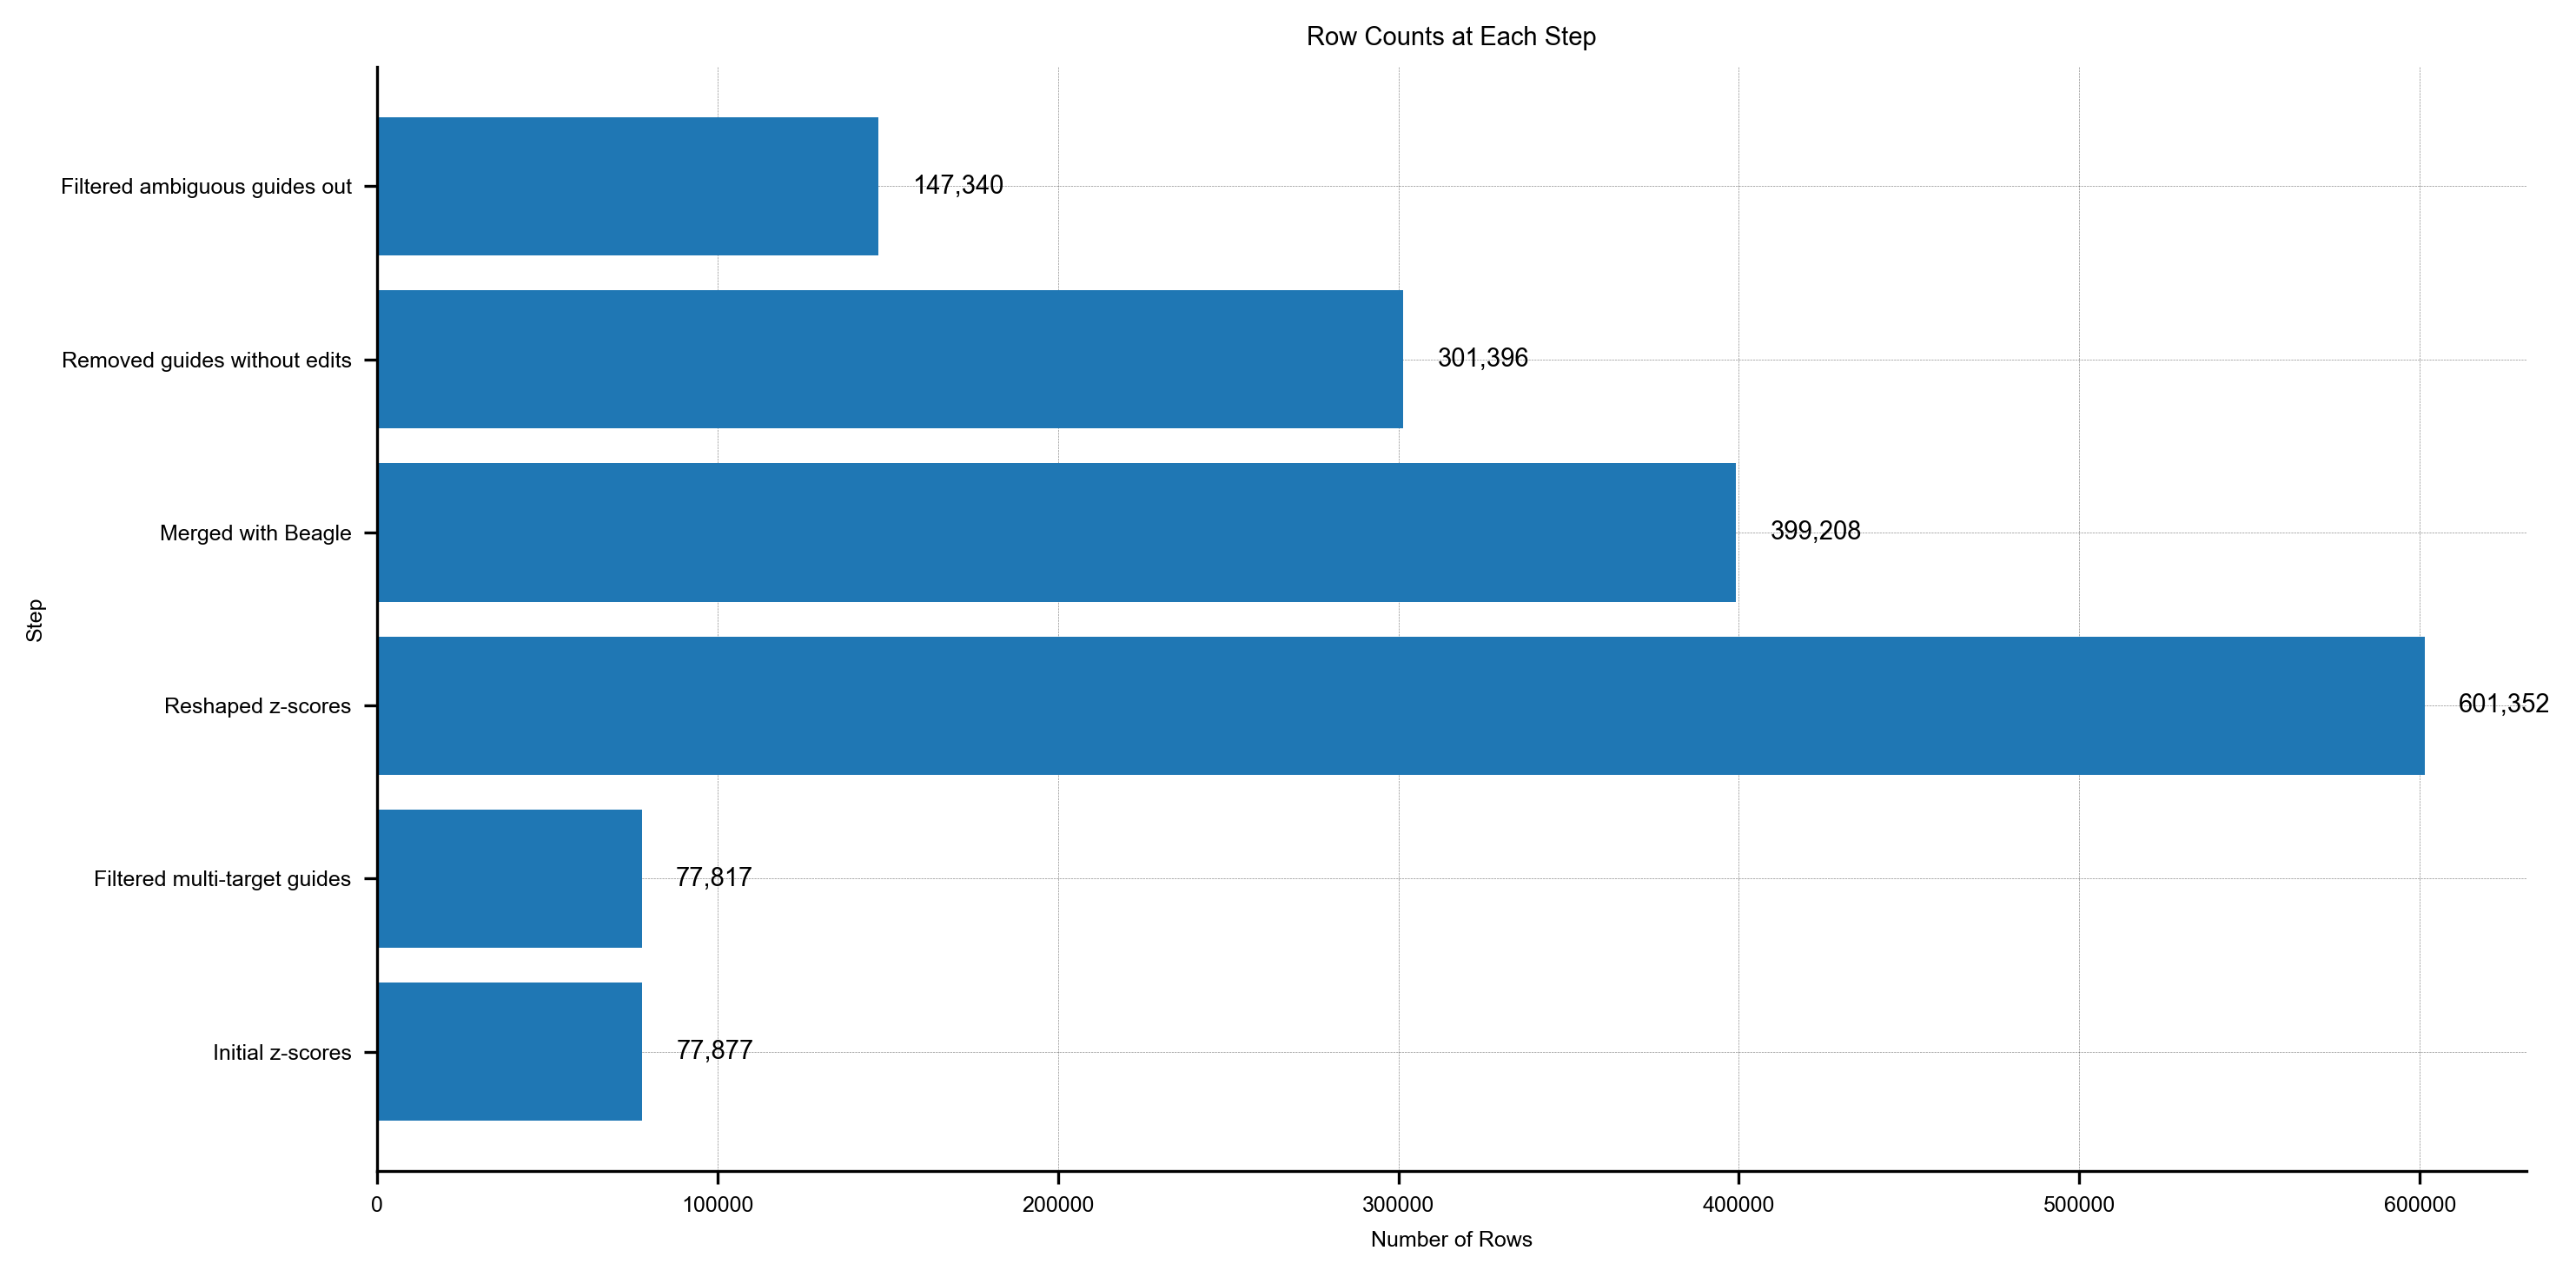

In [118]:
plt.figure(figsize=(10, 5))

# Horizontal bar chart
bars = plt.barh(tracking_row_count["Step"], tracking_row_count["Rows count"])

# Set chart title and axis labels
plt.title("Row Counts at Each Step")
plt.xlabel("Number of Rows")  # Now on the x-axis
plt.ylabel("Step")            # Step names now on the y-axis

# Annotate each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10000, bar.get_y() + bar.get_height()/2, f"{width:,}",
             va='center', fontsize=7)

plt.tight_layout()
plt.show()

### Number of unique guides per step

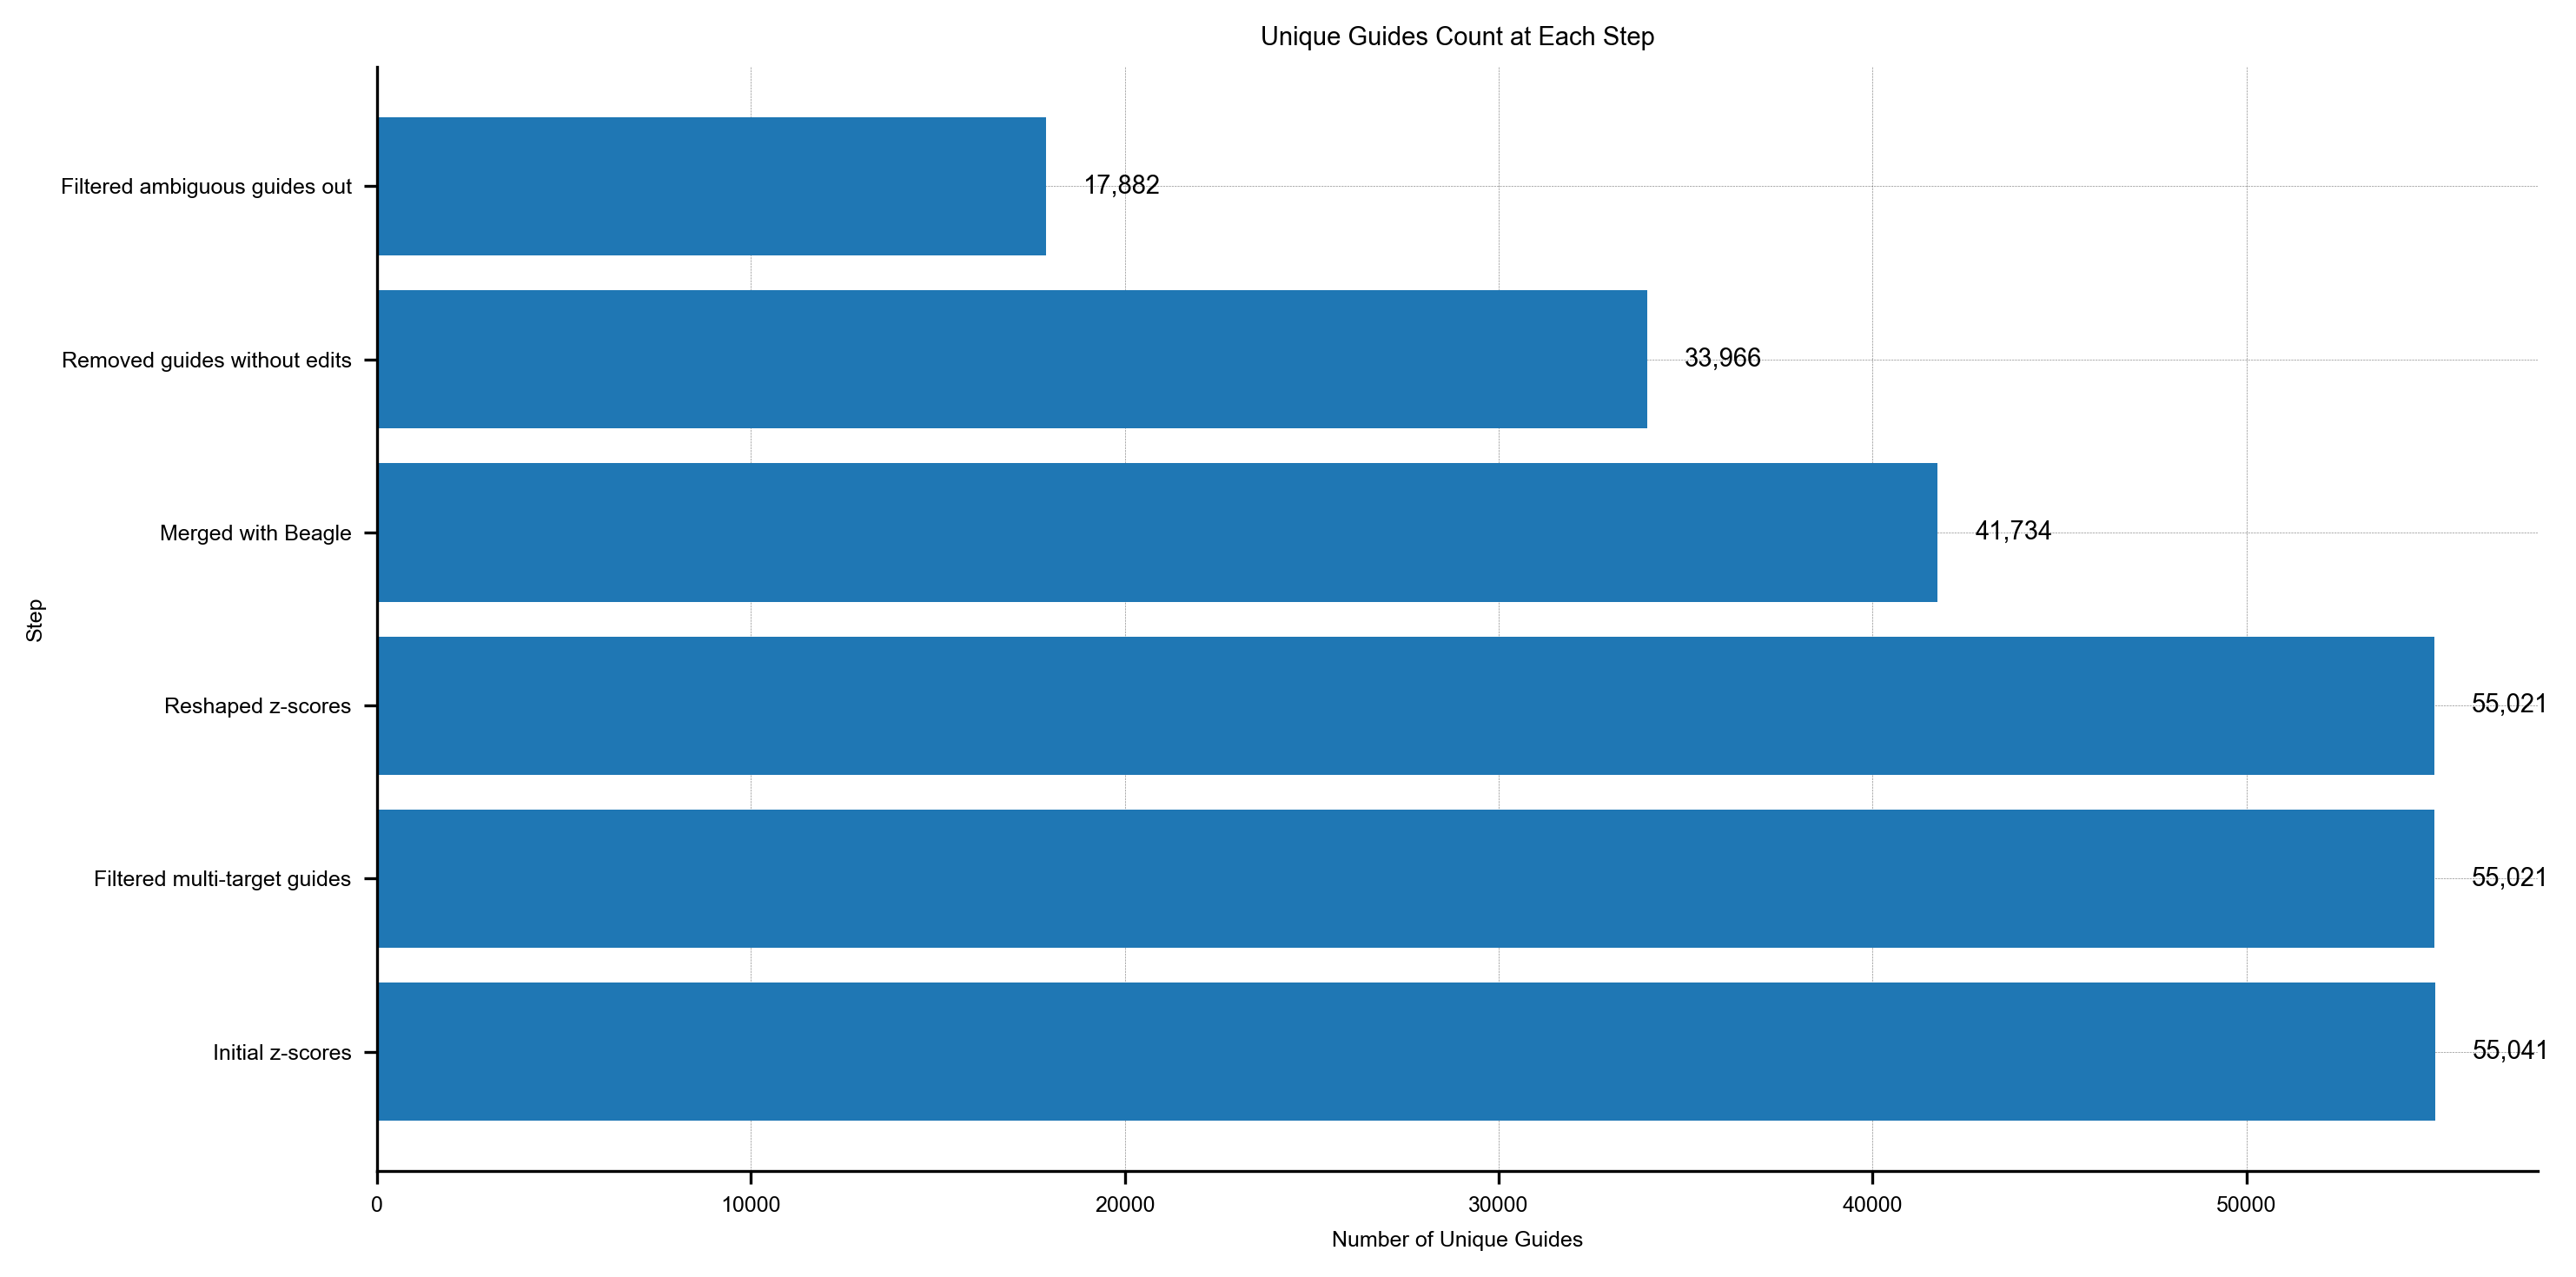

In [116]:
plt.figure(figsize=(10, 5))

# Horizontal bar chart
bars = plt.barh(tracking_unique_guides["Step"], tracking_unique_guides["Unique guides count"])

# Add title and axis labels
plt.title("Unique Guides Count at Each Step")
plt.xlabel("Number of Unique Guides")
plt.ylabel("Step")

# Annotate each bar with the value
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1000, bar.get_y() + bar.get_height()/2, f"{width:,}",
             va='center', fontsize=7)

plt.tight_layout()
plt.show()